# Lecture 1: Discrete Time Markov Chains

In this lecture, we will try to understand how to perform simulations of DTMC systems and perform some tests to discover their properties. \
We will neglect to treat very naive scenarios to focus directly in something more useful. \
For the following pieces of code we will use the following libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

## Exercise 1: Oversimplified Malthusian System

Let's start from a over-simplified, yet useful, version of a problem: let's suppose to have a population of size $N(t)\in\mathbb{N}\cup\{0\}$. \
At every time instant our population can either grow or shrink of one individual. \
The growth process is governed by a certain positive parameter $\lambda$ and the death process by the parameter $\mu$. \
Therefore this Malthusian system can be described by the following updates:

$$
\begin{cases}
N \quad\xrightarrow{p=\lambda} & N+1\\
N \quad\xrightarrow{p=\mu} & N-1 \\
N \quad\xrightarrow{p=(1-\mu-\lambda)} & N
\end{cases}
$$

Let's suppose also for now that $N\leq100$ thus our system can only have a limited number of states/sizes. \
Having a finite number of states we can treat it using the transition matrix approach.

In [2]:
class OSMalth(object):

    # CONSTRUCTOR:
    # given the lambda and the mu of the process we will immediately
    # produce the transition matrix for the system.
    def __init__(self,lamb: float,mu: float, size : int = 101)->None:
        # First let's check some properties:
        if(lamb<0 or mu<0):
            raise RuntimeError("One of the two parameters is negative.")
        if(lamb+mu>1):
            raise RuntimeError("The total probability is bigger than 1.")

        # Now we can create the matrix
        self._size = size
        self.transition_mat = np.diag([1-lamb-mu]*self._size,k=0) #central diag
        self.transition_mat += np.diag([mu]*(self._size-1),k=-1) #lower diag
        self.transition_mat += np.diag([lamb]*(self._size-1),k=1) #upper diag
        self.transition_mat[0,0] += mu #Correct the first element
        self.transition_mat[-1,-1] += lamb #and the last one

        return


    def projectForward (self, n_step: int, p0: np.ndarray) -> np.ndarray:
        """
        Given an initial probability distribution (checks performed), this
        function will return the probability distribution after n_steps.
        """

        # Check if the dimension of p0 is compatible and if n_step is positive
        if len(p0)!=self._size:
            raise RuntimeError("Initial distribution has a different number of state in comparison with the system.")
        if n_step<=0:
            raise RuntimeError("Negative or null number of steps.")
        if p0.sum()>1.0 or (np.abs(p0).sum())!=p0.sum():
            raise RuntimeError("The given vectory is not a probability vector.")

        # Now we can simulate
        matpow = self.transition_mat
        for i in range(1,n_step):
            matpow = np.matmul(matpow,self.transition_mat)

        return np.array(np.dot(p0,matpow))


    def computeTraj ( self, n_step: int, p0: np.ndarray ) -> np.ndarray:
        """
        Given an initial probability distribution (checks performed),
        this function will return a 2D array as column the probability after n-th time steps
        """

        # Check if the dimension of p0 is compatible and if n_step is positive
        if len(p0)!=self._size:
            raise RuntimeError("Initial distribution has a different number of state in comparison with the system.")
        if n_step<=0:
            raise RuntimeError("Negative or null number of steps.")
        if p0.sum()>1.0 or (np.abs(p0).sum())!=p0.sum():
            raise RuntimeError("The given vectory is not a probability vector.")

        # First we need to prepare the output
        output = np.zeros((self._size,n_step+1),dtype=float)
        output[:,0] = p0
        
        # Now we can simulate
        matpow = self.transition_mat
        for i in range(1,n_step):
            output[:,i] = np.array(np.dot(p0,matpow))
            matpow = np.matmul(matpow,self.transition_mat)

        output[:,-1] = np.array(np.dot(p0,matpow))

        return output

Created the class, let's check it works correctly with an example

<BarContainer object of 100 artists>

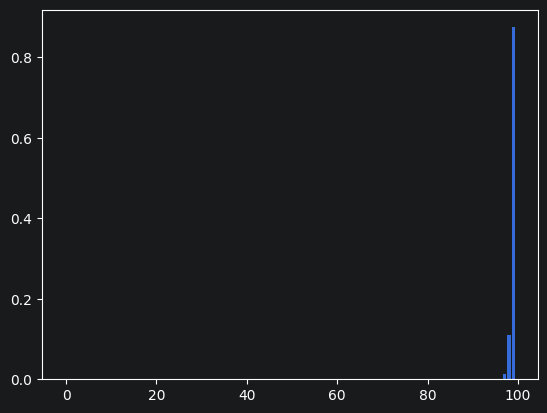

In [38]:
# Define parameters
size = 100
n_step = 25
# Prepare the initial distribution
p = np.zeros(size, dtype = float)
p[99] = 1.0

# Create the model
dtmc = OSMalth(lamb = 0.8, mu = 0.1, size = size)


# Compute the projection
p = dtmc.projectForward(n_step = n_step, p0 = p)

#Plot
x = np.arange(0, size)
plt.bar(x, p)

We can also try to produce an entire trajectory and plot it in the time

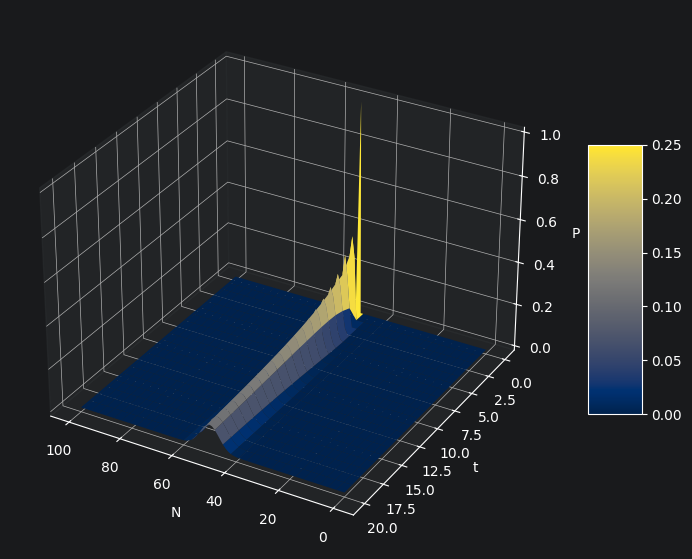

In [17]:
# Create the system
size = 101
n_step = 20
dtmc = OSMalth(lamb = 0.3, mu = 0.3)

# Prepare the initial distribution
p = np.zeros(size, dtype = float)
p[50] = 1.0

# Produce trajectory
p = dtmc.computeTraj(n_step = n_step, p0 = p)

#Plot
t = np.linspace(0, n_step, n_step+1)
x = np.linspace(0, size-1, size)

T,X = np.meshgrid(t,x)

fig = plt.figure(figsize = (10, 7))
ax = fig.add_subplot(111, projection = '3d')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('N')
ax.set_ylabel('t')
ax.set_zlabel('P')
surf = ax.plot_surface(X, T, p, cmap = 'cividis')

plt.colorbar(surf, shrink = 0.5, aspect = 5)

We can try now to study the bifurcations for our system, by performing some qualitative analysis.

It is trivial to deduce that the entire process is based in its invariant measure/steady state behaviour on the ratio between $\lambda$ and $\mu$. \
Indeed, by simply looking at its equation, it is easy to understand that our system is characterize by the following master equation:

$$
\frac{\Delta P(n,t)}{\Delta t}=\lambda P(n-1,t)+\mu P(n+1,t)-(\lambda+\mu)P(n,t)
$$

This is obviously valid only in the core region and not along the borders. \
At the steady state the left-hand variation is null: to find the steady-state, thus, we need to solve this equation:

$$
0 \equiv \lambda P_s(n-1)+\mu P_s(n+1)-(\lambda+\mu)P_s(n)
$$

Notice that, because of the steady-state property, the dependence on time $t$ is lost. \
We can divide everything for $\mu$, getting:

$$
r P_s(n-1) + P_s(n+1) - (1+r)P_s(n) = 0 \qquad\qquad r := \lambda/\mu
$$

And rearranging terms we obtain:

$$
r\left(P_s(n-1)-P_s(n)\right) + \left(P_s(n+1)-P_s(n)\right) = 0
$$

The first term is an upperflow, the second term is a downflow. \
Thus, according to the value of $r$, except when $r\simeq1$, we will have that one of the two flows is dominant.

Let's verify it!

<BarContainer object of 101 artists>

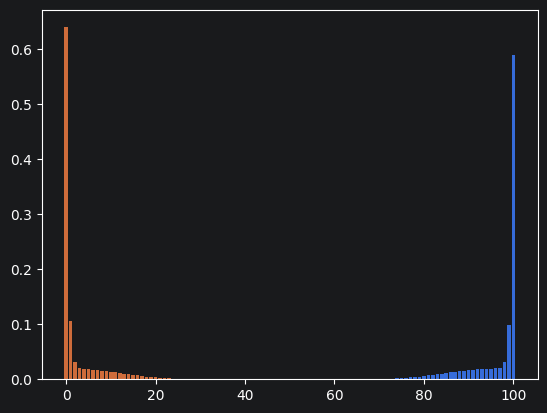

In [18]:
# Define parameters
size = 101

# Create the system
dtmc_l = OSMalth(0.7,0.1) # HIGH LAMBDA
dtmc_m = OSMalth(0.1,0.7) # HIGH MU

# Prepare the initial distribution. Now, we use a uniform distribution in the central part
p_l = np.zeros(size,dtype=float)
p_m = np.zeros(size,dtype=float)
for i in range(24,74):
    p_l[i] = 0.02
    p_m[i] = 0.02

# Produce trajectory
p_l = dtmc_l.projectForward(size-1, p_l)
p_m = dtmc_m.projectForward(size-1, p_m)

x = np.arange(0, size)
plt.bar(x,p_l)
plt.bar(x,p_m)

The situation for $r=1$ is particularly interesting. Analyzing it we can find that:

$$
    P_s(n+1)+P_s(n-1)-2P_s(n) = 0
$$

It is trivial by induction from the borders that $P_s(n)\equiv c\in\mathbb{R}^+$, $\forall n\in\mathbb{N}\cup\{0\}\wedge n\leq100$. In other term this means that for $r=1$ the system will behave as a *random walk*.

In [ ]:
# Define parameters
size = 101

# Create the system
dtmc_l = OSMalth(0.7,0.1) # HIGH LAMBDA
dtmc_m = OSMalth(0.1,0.7) # HIGH MU
dtmc_e = OSMalth(0.5,0.5) # PARITY

# Prepare the initial distribution. This time we use a uniform distribution in the central part
p_l = np.zeros(size,dtype=float)
p_m = np.zeros(size,dtype=float)
p_e = np.zeros(size,dtype=float)
for i in range(24,74):
    p_l[i] = 0.02
    p_m[i] = 0.02
    p_e[i] = 0.02

# Produce trajectory
p_l = dtmc_l.projectForward(size-1, p_l)
p_m = dtmc_m.projectForward(size-1, p_m)
p_e = dtmc_e.projectForward(size-1, p_e)

x = np.arange(0, size)
plt.bar(x,p_l)
plt.bar(x,p_m)
plt.bar(x,p_e)

## Exercise 2: Logistic system

Now we can start to relax the things a bit and transform our model in something a little more realistic.

The first hypothesis we are going to remove is the maximum size. \
Now let's simply suppose that $n\in\mathbb{N}\cup\{0\}$. \
Relaxing this hypothesis is actually quite problematic for our numerical method. In fact having no limit in the size of the system does not allow us to use the transition matrix method (there will be actually a way but is extremely critical and inefficient), therefore we will need to try something new: *sampling trajectories*!

The second thing we want to modify is the system itself. \
The Malthusian growth is, in fact, not so realistic, and thus we will move to a logistic version.

Given a logistic population size $K$ we will have:

$$
\begin{cases}
N \quad\xrightarrow{p = \lambda_N} & N+1\\
N \quad\xrightarrow{p = \mu_N} & N-1 \\
N \quad\xrightarrow{p= (1-\mu_N-\lambda_N)} & N
\end{cases}
$$

Where $\mu_N$ is taken as $\mu_N:=\mu N+\frac{\lambda-\mu}{K}N^2$ and $\lambda_N:= \lambda N$. \
We need to implement in this shape the system to have the exact transposition of the logistic growth.

However, look at the rate expression: there is a huge problem!
Having a dependency on the variable transforms this parameters in a rate: it is not a probability!

To solve this problem, there are no nice and clean solutions; we need to do some assumptions (we are starting here some issues regarding the DTMC). \
We need to re-set a maximum possible size of the population for our dynamics. \
In other terms, we have to choose/find a number which is high enough we are sure that the population dynamic will not be able to reach it (except for some pathological cases); an example would be $N_{max}=2K$.
By doing this, we will need to normalize everything divinding for:

$$
\mathcal{M} := \lambda N_{max}+\mu N_{max}+\frac{\lambda-\mu}{K}N_{max}^2
$$

This operation obviously produces some kind of influences on the transient behavior, in particular on the speed. \
In fact, dividing a rate for a given value is like using a time unit with a different length.
However, we are mostly interested in the steady state behavior, and therefore it is not too much of a problem. \
Still, this is already showing us why for certain kinds of applications the CTMC is a more favorable choice.

FInally, this choice is still problematic: can you guess the reason?

As one can immediately notice, the bound implies some changes both for the model and for the numerical methods. \
For the latter, since we can potentially have an infinite population size, we will need to abandon the transition matrix.

Working with stochastic systems (sometimes with deterministic ones too), the analysis of the system is conducted via sampling of trajectories. \
The idea is trivial: for the configuration of parameters and of the initial conditions we produce $M$ trajectories/realizations of the system; using them we will get the probability distribution (or whatever statistical momenthum we need).

Therefore, let's define the new system and our new numerical method:

In [39]:
class OSLog(object):

    # CONSTRUCTOR: we will need the lambda, the mu and the logistic size K
    def __init__(self,lamb: float,mu: float,k: int)->None:
        # First let's check some properties:
        if lamb<0 or mu<0 or k<0:
            raise RuntimeError("One of the parameters is negative.")
        if lamb+mu > 1:
            raise RuntimeError("The total probability is bigger than 1.")

        self._lambda = lamb
        self._mu = mu
        self._K = k
        self._coeff = (lamb-mu)/k
        self._norm = lamb*k*2 + mu*k*2 + self._coeff*k*k*4

        # We add a print to have an idea of how much is our equivalent time unit:
        print("EQUIVALENT TIME UNIT: ", 1.0/self._norm)


    def __computeInitialState__(self,p0: np.array)->int:
        """
        Given a probability vector (no check performed) of the initial
        state, this method will return the initial state.
        The returned state will be a slot index of the vector.
        """
        # For the initial state, we simply opt to consider the slot as
        # the initial size of the system.

        # First we need to get the cumulative probability distribution
        p_init = p0.copy()
        for i in range(1,len(p_init)):
            p_init[i] += p_init[i-1]

        r = random.uniform(0,1) #Create a random prob value

        for i in range(len(p_init)):
            if r<=p_init[i]:
                return i

        raise RuntimeError("Something went wrong during the computation of the initial state.")
        return 0

    def computeTraj(self, n_step: int,p0: np.ndarray)->np.ndarray:
        """
        Given an initial probability distribution (checks performed), this
        function will return a 2D array as column the probability after n-th
        time steps
        """

        #Check if p0 is a probability distribution and if n_step is positive
        if n_step<=0:
            raise RuntimeError("Negative or null number of steps.")
        if p0.sum()>1.0 or (np.abs(p0).sum())!=p0.sum():
            raise RuntimeError("The given vectory is not a probability vector.")

        # First we need to prepare the output and sort the initial position of the realization
        output = np.zeros(n_step+1,dtype=float)
        output[0] = self.__computeInitialState__(p0)

        # Now at every time step we need to find which transition will take place
        for i in range(1,n_step+1):
            #First we need to compute actual lambda and mu
            l_N = self._lambda*output[i-1]/self._norm
            m_N = (self._mu*output[i-1]+self._coeff*output[i-1]*output[i-1])/self._norm

            r = random.uniform(0,1) # Produce a random number

            if r<l_N: # New born
                output[i] = output[i-1]+1
            elif r<(l_N + m_N): # New death
                output[i] = output[i-1]-1
            else: # Remain the same (N=0 is included here)
                output[i] = output[i-1]
                
        return output

Created the class we can now try to produce a trajectory to see if everything works correctly:

EQUIVALENT TIME UNIT:  0.004545454545454545


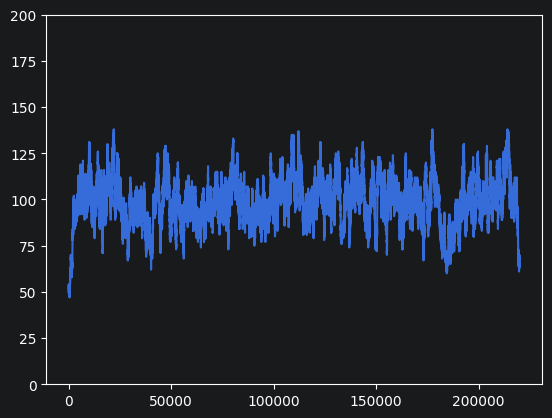

In [54]:
# Create the system
dtmc = OSLog(0.4,0.1,100)

# Prepare the initial distribution
p = np.zeros(51,dtype=float)
p[50] = 1.0

# Compute the projection
p = dtmc.computeTraj(220000,p) #EQUIVALENT TO 100

# Plot
x = np.arange(0,220001)
plt.ylim(0,200)
plt.plot(x,p)

Ok, it looks good. Certainly we have a much higher granularity due to the smaller time unit. The system is actually instable at the steady state due to the abscence of the noise suppression which creates an equal probability condition but not a no-flow condition. Now we can try to compute the steady state PDF for this system. The idea is simply to produce $M=1000$ simulations and then use the last point of each of them to produce a bin system. Obviously we require to take random initial position to have an unbiased sampling.

EQUIVALENT TIME UNIT:  0.004545454545454545


<BarContainer object of 201 artists>

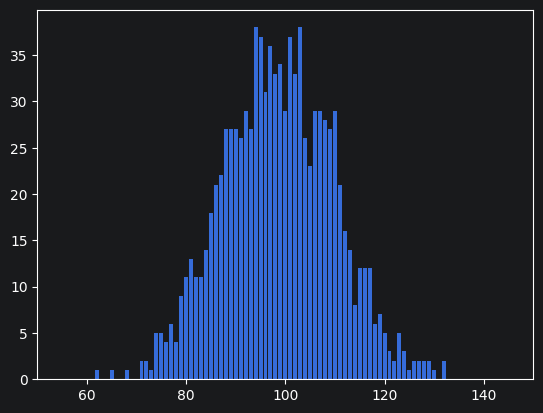

In [56]:
#Create the system
dtmc = OSLog(0.4,0.1,100)
M = 1000

#Prepare the initial distribution
p = np.zeros(200,dtype=float)
for i in range(50,150):
    p[i] = 0.01

#Now we can compute all the simulations
final_states = np.zeros(M,dtype=int)
for i in range(M):
    final_states[i] = dtmc.computeTraj(22000,p)[-1]

#And then produce the binning
bins = np.zeros(201,dtype=int)
for i in range(M):
    bins[final_states[i]] += 1

#Plot
x = np.linspace(0,200,201)
plt.xlim(50,150)
plt.bar(x,bins)

To compute the evolution in time we need to keep all the intermediate states:

EQUIVALENT TIME UNIT:  0.004545454545454545


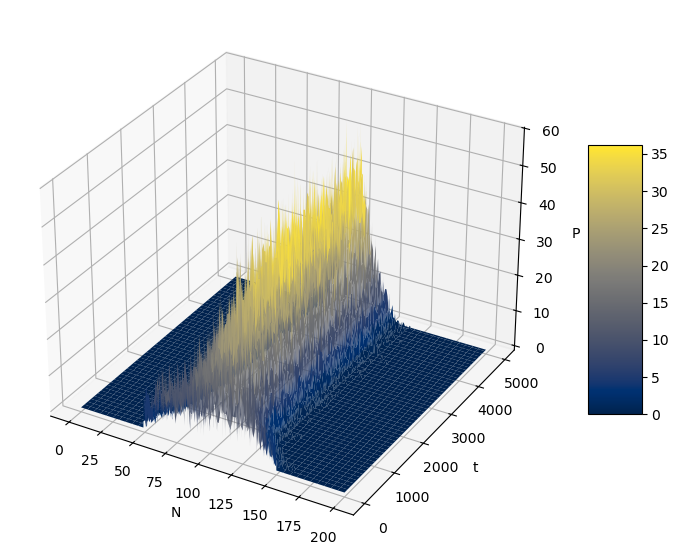

In [10]:
#Create the system
dtmc = OSLog(0.4,0.1,100)
M = 1000

#Prepare the initial distribution
p = np.zeros(200,dtype=float)
for i in range(50,150):
    p[i] = 0.01

#Now we can compute all the simulations
trajs = np.zeros((22001,M),dtype=int)
for i in range(M):
    trajs[:,i] = dtmc.computeTraj(22000,p)

#And then produce the binning
bins = np.zeros((22001,201),dtype=int)
for i in range(22001):
    for j in range(M):
        bins[i,trajs[i,j]] += 1

#Plot
t_max = 5000
t = np.linspace(0, t_max, t_max + 1)
x = np.linspace(0, 200, 201)
T, X = np.meshgrid(t, x)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('N')
ax.set_ylabel('t')
ax.set_zlabel('P')

surf = ax.plot_surface(X, T, bins[:t_max+1, :].transpose(), cmap='cividis')
plt.colorbar(surf, shrink=0.5, aspect=5)

Once again, we can try to study the bifurcations for our system. The parameters $K>0$ is not, at least theoretically, able to produce bifurcations for our system because it is only able to determine the position of the attractor. For the relationships between $\lambda_N$ and $\mu_N$ we can similarly start from the master equation above finding that:

$$
\lambda_{N-1}P_s(N-1)+\mu_{N+1}P_s(N+1)-(\lambda_N+\mu_N)P_s(N)=0
$$

This time the parameters are not actually constant but simple *converters*. We need to make explicit the expression: 

$$
\frac{\lambda(N-1)}{\mathcal{M}}P_s(N-1)+\frac{\mu(N+1)}{\mathcal{M}}P_s(N+1)+\frac{1}{\mathcal{M}}\frac{\lambda-\mu}{K}(N+1)^2P_s(N+1)-\frac{\lambda N}{\mathcal{M}}P_s(N)-\frac{\mu N}{\mathcal{M}}P_s(N)-\frac{1}{\mathcal{M}}\frac{\lambda-\mu}{K}N^2P_s(N)=0
$$

Now we have to make some hypothesis: we are working with sizes around $N\sim 100$ or, in other terms, $N\in O(2)$. Thus we can divide for $N$ and use this to simplify $N-1$ or $N+1$. We can also remove $\mathcal{M}$ in every term. Dividing all for $\mu$ we obtain:

$$
r P_s(N-1)+P_s(N+1)+(r-1)\frac{N}{K}P_s(N+1)-rP_s(N)-P_s(N)-(r-1)\frac{N}{K}P_s(N) \cong 0
$$

We have almost finish: if we are going now to reorder the terms in the following shape we can notice some things...

$$
r\left[\left(P_s(N-1)-P_s(N)\right)+\frac{N}{K}\left(P_s(N+1)-P_s(N)\right)\right]+\left[\left(P_s(N+1)-P_s(N)\right)-\frac{N}{K}\left(P_s(N+1)-P_s(N)\right)\right]=0
$$

We have once again a bunch of fluxes. If we look to the solutions independently by $N$ at first, we find once again that the value of $r$ dominates the behaviour. If $r\gg 1$ we have an upper flow and a lower flow which becomes stronger than the upper flow when $N>K$. Therefore in this situation the system has as only attractor the carry capacity. 

However some problems arise when $r\ll 1$. In fact in this situation, we have only the right term where we have a down flow but there is also an upper flow. When $N$ is small there is no problem but we can notice that for growing $N$ the flow becomes smaller. In fact, in term of transitions, when $r<1$ we have a switch tha transforms 0 in an attractive point and the capacity in a repulsor. The only thing that is trying to save this is that at $N=K$ there should be no flow but pratically this is very fragile in a simulative context. If, for some reasons, $N>K$ the solution will start to diverge because it will be repulse to higher value. This already produce a limit that allows us to simulate only on the region below the carry capacity. Moreover, we have also another problem: the norm before for $\mu>\lambda$ (so no only in the extreme $r\ll 1$ situation) could be negative for certain combinations of $N$.

Are there other solutions? Yes but mostly all of them have some problems. One possible is to substitute $\lambda-\mu$ with $\lambda$. With this choice there will be no problem of negativity of the norm but we are losing the symmetry that allowed us to have a symmetric flux in $K$ but the carrying point will move to a different:

$$
K_{eff}=\frac{\lambda-\mu}{\lambda}K
$$

However, as you can notice, this can solve the problem of $\mu>\lambda$ because the carry capacity point will move outside the domain leaving 0 as attractive (in an SD situatation, this is called a *transcritical bifurcation*)

## Exercise 3: Cellular Automata

Until now we have looked to some didactical applications which can be used more to understand the topic than to have a real grasp of the possible applications. Now a days, the usage of the DTMC for population problems or complex problems is quite low. On one side we can have the problem in describing non trivial scenarios without introducing approximations but there are also other issues. If we abbandon the possibility to move only one step up or down we start to have some continuity problems and we start to move inside the incredibly insidious, yet stunning, world of the *stochastic iterative maps*. On the other hand, this discretization, there are some studies regarding this, is often not realistic at all. Therefore, there are usually two solutions: using CTMC (if we want to give importante to the discretization of system) or dynamic systems based on SDE. But this is not the end for the DTMC...

On application of the DTMC, it is the systems of Cellular Automata. The Cellular Automaton (CA) is a possible type of agent (thus ABM approach) which act in certain way as a probabilistic (but also deterministic) minimal robot that adjust its probabilities to switch status according to external variables or the status of the other CAs composing the system. This CAs are extremely useful in a lot of field from the biology to the computer science and can be customize in multiple ways. In most of the cases the CAs are positioned on a spatial structure or graph with defined neighbourhoods but it is not mandatory.

Let's consider than the following example: we have a squared grid of 64 CA. Each of them is linked with the neighbors following the *von Neumann rule* or known as *rook*. The rook neighbourhood given a point of the grid (x,y) is made of:

$$
Neigh(x,y) = \left\{(x-1,y),(x+1,y),(x,y-1),(x,y+1)\right\}
$$

Let's suppose that the state of each CA is binary and has the following transitions:

- If $S=0$ (deactivated), we have probability to activate $P_1(K)=\frac{\rho_1}{2}f(K)$ where $f(K)= K \Leftrightarrow K\in\{1,2\}$ otherwise $f(K)\equiv 0$
- If $S=1$ (activated), we have probability to deactivate $P_0(K)=\frac{\rho_2}{2}g(K)$ where $g(K)= K-2 \Leftrightarrow K\in\{3,4\}$ otherwise $g(K)\equiv 0$

The remaining in the state probability can be easily deduced. Let's also suppose no cyclic conditions at the border of the grid.

It is quite clear that in our system every CA will evolve as a DTMC with varying probability. Certainly each of them will be not independent by the other thus we need to evolve every CA step by step at the same time. To implement this we have quite a lot of things to do!

In [44]:
class CAsystem(object):

    #CONSTRUCTOR: we need to pass the two base probability rho1 and rho2
    def __init__(self,r1: float,r2: float)->None:

        #The grid characteristics are given and fixed
        self._size = 64
        self._shape = 8

        #Set the parameters
        self._rho1 = r1
        self._rho2 = r2

        #Create adjacency list
        self._adjList = self.__createAdjList__()
        
        return

    #ADJACENCY LIST CREATION
    def __createAdjList__(self):
        """
        This function will create an adjacency list for a rook
        neighbourhood.
        """
        #Create the empty list
        adj = []

        for i in range(self._size):
            local_adj = []

            #Check if it is not in the first row:
            if(i//self._shape!=0):
                local_adj.append(i-self._shape)
            #Check if it is not in the first column:
            if(i%self._shape!=0):
                local_adj.append(i-1)
            #Check if it is not in the last column:
            if((i+1)%self._shape!=0):
                local_adj.append(i+1)
            #Check if it is not in the last row:
            if(i//self._shape!=self._shape-1):
                local_adj.append(i+self._shape)

            adj.append(local_adj)
        
        return adj

    #ACTIVATION PROBABILITY FUNCTION
    def __probF__(self,K: int)->float:
        '''
        Given the number of neighbours K, this function will return
        the activation probability.
        '''
        if(K==1 or K==2):
            return self._rho1*K/2
        else:
            return 0

    #DEACTIVATION PROBABILITY FUNCTION
    def __probG__(self,K: int)->float:
        '''
        Given the number of neighbours K, this function will return
        the activation probability.
        '''
        if(K==3 or K==4):
            return self._rho2*K/2
        else:
            return 0

    #EVOLVE THE CA
    def __evolveCA__(self,s: int,k: int)->int:
        '''
        Given the actual status of a CA and the number of infects,
        return the new status for the CA.
        '''

        r = random.uniform(0,1)

        if(s==0): #Try to activate
            if(r<=self.__probF__(k)):
                return 1
        else: #Try to deactivate
            if(r<=self.__probG__(k)):
                return 0

        #otherwise be the same
        return s

    def computeTraj(self,n_step: int,s0: np.array)->np.array:
        '''
        Given the number of steps and the initial status of the system,
        this function will produce a trajectory for the CA system.
        '''

        #First we perform some checks
        if(n_step<0):
            raise RuntimeError("Number of steps is negative.")
        if(len(s0)!=self._size):
            raise RuntimeError("Initial status vector has a size different from the system size.")
        for i in range(self._size):
            if(s0[i]!=0 and s0[i]!=1):
                raise RuntimeError("An automaton can have only 0 or 1 as status.")

        #Setup the output array
        traj = np.zeros((self._size,n_step+1),dtype=int)
        traj[:,0] = s0

        for i in range(1,n_step+1):
            #Evolve each automata:
            for j in range(self._size):

                #We need first to compute the number of infected neighbours
                K = 0
                for k in range(len(self._adjList[j])):
                    if(traj[k,i-1]==1):
                        K += 1
                
                traj[j,i] = self.__evolveCA__(traj[j,i-1],K)

        return traj
                

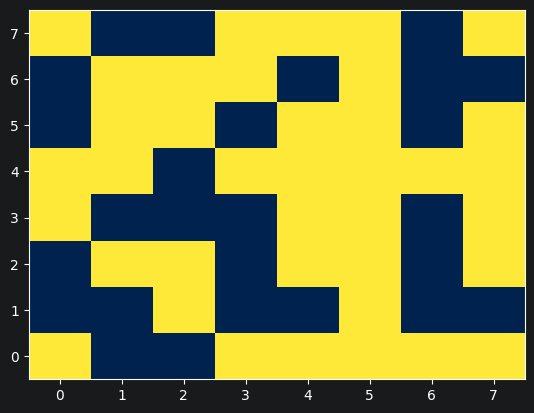

In [51]:
ca = CAsystem(0.2,0.15)

s0 = np.zeros(64,dtype=int)

for i in range(64):
    if(i%2==0):
        s0[i] = 1

t = ca.computeTraj(100,s0)

grid = t[:,20].reshape(8,8)
mesh = plt.pcolormesh(grid, cmap='cividis', shading='nearest')